# Prediction of Heavy AI User


## Importing libaries

Libraries used : **numpy**, **pandas**, **matplotlib**, **scikit-learn**.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
np.set_printoptions(precision=4, suppress=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Problem and Data Description

### Πρόβλημα

Το πρόβλημα είναι **δυαδική ταξινόμηση** και θέλουμε να προβλέψουμε αν ένας χρήστης είναι heavy χρήστης AI.

Ένας χρήστης είναι heavy χρήστης AI αν το AI_Usage_Hours_Per_Week >= 7.17.

### Dataset

Το dataset έχει 15.000 εγγραφές και 13 αρχικές στήλες:

- `User_ID`: η στήλη αυτή αφαιρείται
- `Country`, `State`: γεωγραφικά κατηγορικά χαρακτηριστικά
- `Age`, `Gender`, `Device_Type`: δημογραφικά χαρακτηριστικά
- `AI_Usage_Hours_Per_Week`: χρησιμοποιείται μόνο για τη δημιουργία target και μετά αφαιρείται
- `Data_Usage_GB_Month`, `Data_Cost_Per_GB_USD`, `Monthly_Data_Bill_USD`: χαρακτηριστικά χρήσης και κόστους δεδομένων
- `Digital_Literacy_Score`: αριθμητικό χαρακτηριστικό ψηφιακής ετοιμότητας
- `Has_5G_Access`: κατηγορικό χαρακτηριστικό Yes/No
- `Primary_AI_Use_Case`: κατηγορικό χαρακτηριστικό

In [ ]:
# Φόρτωση του dataset
df_raw = pd.read_csv("global_ai_consumption_dataset.csv")

print("Αρχικό σχήμα dataset:", df_raw.shape)
print("Στήλες:")
print(list(df_raw.columns))

Αρχικό σχήμα dataset: (15000, 13)
Στήλες:
['User_ID', 'Country', 'State', 'Age', 'Gender', 'Device_Type', 'AI_Usage_Hours_Per_Week', 'Primary_AI_Use_Case', 'Data_Usage_GB_Month', 'Data_Cost_Per_GB_USD', 'Monthly_Data_Bill_USD', 'Has_5G_Access', 'Digital_Literacy_Score']


### Δημιουργία target και άμεσο train/test split

Oρίζουμε `X` και `y`, και μετά κάνουμε train/test split

In [ ]:
TARGET_THRESHOLD = 7.17

# Δημιουργία target
y = (df_raw["AI_Usage_Hours_Per_Week"] >= TARGET_THRESHOLD).astype(int)
y.name = "Heavy_AI_User"

# Αφαίρεση ID και leakage column
X = df_raw.drop(columns=["User_ID", "AI_Usage_Hours_Per_Week"])

# Stratified train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

print("\nΚατανομή target στο train:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion").to_frame())

print("\nΚατανομή target στο test:")
display(y_test.value_counts(normalize=True).sort_index().rename("proportion").to_frame())

assert "User_ID" not in X_train.columns
assert "AI_Usage_Hours_Per_Week" not in X_train.columns

Train: (12000, 11) (12000,)
Test:  (3000, 11) (3000,)

Κατανομή target στο train:


,proportion
Heavy_AI_User,
0,0.699583
1,0.300417



Κατανομή target στο test:


,proportion
Heavy_AI_User,
0,0.699667
1,0.300333


### Exploratory Data Analysis

In [ ]:
train_eda = X_train.copy()
train_eda["Heavy_AI_User"] = y_train

numeric_features = [
    "Age",
    "Data_Usage_GB_Month",
    "Data_Cost_Per_GB_USD",
    "Monthly_Data_Bill_USD",
    "Digital_Literacy_Score",
]

categorical_features = [
    "Country",
    "State",
    "Gender",
    "Device_Type",
    "Has_5G_Access",
    "Primary_AI_Use_Case",
]

print("Αριθμητικά χαρακτηριστικά:", numeric_features)
print("Κατηγορικά χαρακτηριστικά:", categorical_features)

print("\nΠρώτες γραμμές:")
display(train_eda.head())

print("\nΤύποι στηλών:")
display(X_train.dtypes.rename("dtype").to_frame())

Αριθμητικά χαρακτηριστικά: ['Age', 'Data_Usage_GB_Month', 'Data_Cost_Per_GB_USD', 'Monthly_Data_Bill_USD', 'Digital_Literacy_Score']
Κατηγορικά χαρακτηριστικά: ['Country', 'State', 'Gender', 'Device_Type', 'Has_5G_Access', 'Primary_AI_Use_Case']

Πρώτες γραμμές:


,Country,State,Age,Gender,Device_Type,Primary_AI_Use_Case,Data_Usage_GB_Month,Data_Cost_Per_GB_USD,Monthly_Data_Bill_USD,Has_5G_Access,Digital_Literacy_Score,Heavy_AI_User
9926,Indonesia,West Java,17,Female,Desktop,Gaming AI,11.14,0.87,9.74,No,1,1
1168,Germany,Berlin,31,Male,Mobile,Gaming AI,23.82,1.19,28.31,Yes,7,1
8032,Japan,Osaka,40,Female,Desktop,Content Creation,17.87,4.25,76.03,No,6,0
10319,France,Île-de-France,31,Male,Mobile,Coding,17.23,2.01,34.68,Yes,7,1
6353,Australia,Victoria,29,Male,Mobile,Gaming AI,21.56,2.29,49.36,Yes,10,1



Τύποι στηλών:


,dtype
Country,str
State,str
Age,int64
Gender,str
Device_Type,str
Primary_AI_Use_Case,str
Data_Usage_GB_Month,float64
Data_Cost_Per_GB_USD,float64
Monthly_Data_Bill_USD,float64
Has_5G_Access,str


In [ ]:
print("Missing values:")
missing_table = (
    X_train.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)
missing_table["missing_count"] = X_train.isna().sum().loc[missing_table.index]
display(missing_table)

print("\nΒασικά στατιστικά αριθμητικών χαρακτηριστικών:")
display(train_eda[numeric_features].describe().T.round(3))

Missing values:


,missing_rate,missing_count
Primary_AI_Use_Case,0.202833,2434
Country,0.000000,0
State,0.000000,0
Age,0.000000,0
Gender,0.000000,0
Device_Type,0.000000,0
Data_Usage_GB_Month,0.000000,0
Data_Cost_Per_GB_USD,0.000000,0
Monthly_Data_Bill_USD,0.000000,0
Has_5G_Access,0.000000,0



Βασικά στατιστικά αριθμητικών χαρακτηριστικών:


,count,mean,std,min,25%,50%,75%,max
Age,12000.0,45.162,17.067,16.00,30.00,45.00,60.000,74.00
Data_Usage_GB_Month,12000.0,15.029,5.919,0.10,11.02,14.79,18.792,42.56
Data_Cost_Per_GB_USD,12000.0,2.425,1.885,0.05,1.14,1.79,3.150,8.00
Monthly_Data_Bill_USD,12000.0,36.357,33.675,0.03,13.78,25.75,47.292,285.95
Digital_Literacy_Score,12000.0,5.496,2.890,1.00,3.00,6.00,8.000,10.00


,corr_with_target
Age,-0.0766
Data_Cost_Per_GB_USD,-0.0065
Digital_Literacy_Score,0.0011
Monthly_Data_Bill_USD,0.1704
Data_Usage_GB_Month,0.4186


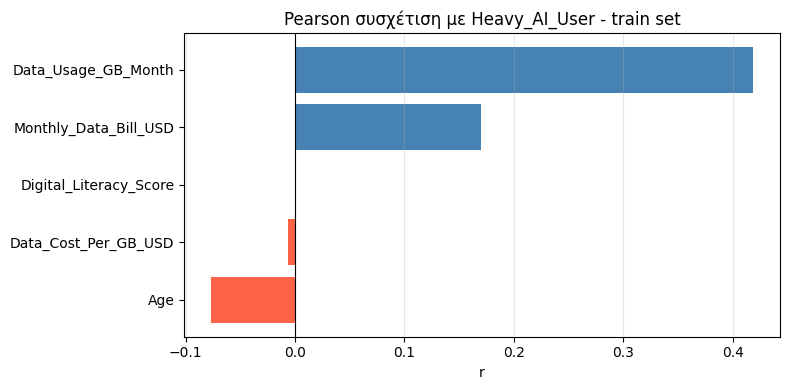

In [ ]:
# Συσχετίσεις αριθμητικών χαρακτηριστικών με το target
corr_train = (
    train_eda[numeric_features + ["Heavy_AI_User"]]
    .corr(numeric_only=True)["Heavy_AI_User"]
    .drop("Heavy_AI_User")
    .sort_values()
)

display(corr_train.rename("corr_with_target").to_frame().round(4))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if value < 0 else "steelblue" for value in corr_train.values]
ax.barh(corr_train.index, corr_train.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson συσχέτιση με Heavy_AI_User - train set")
ax.set_xlabel("r")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

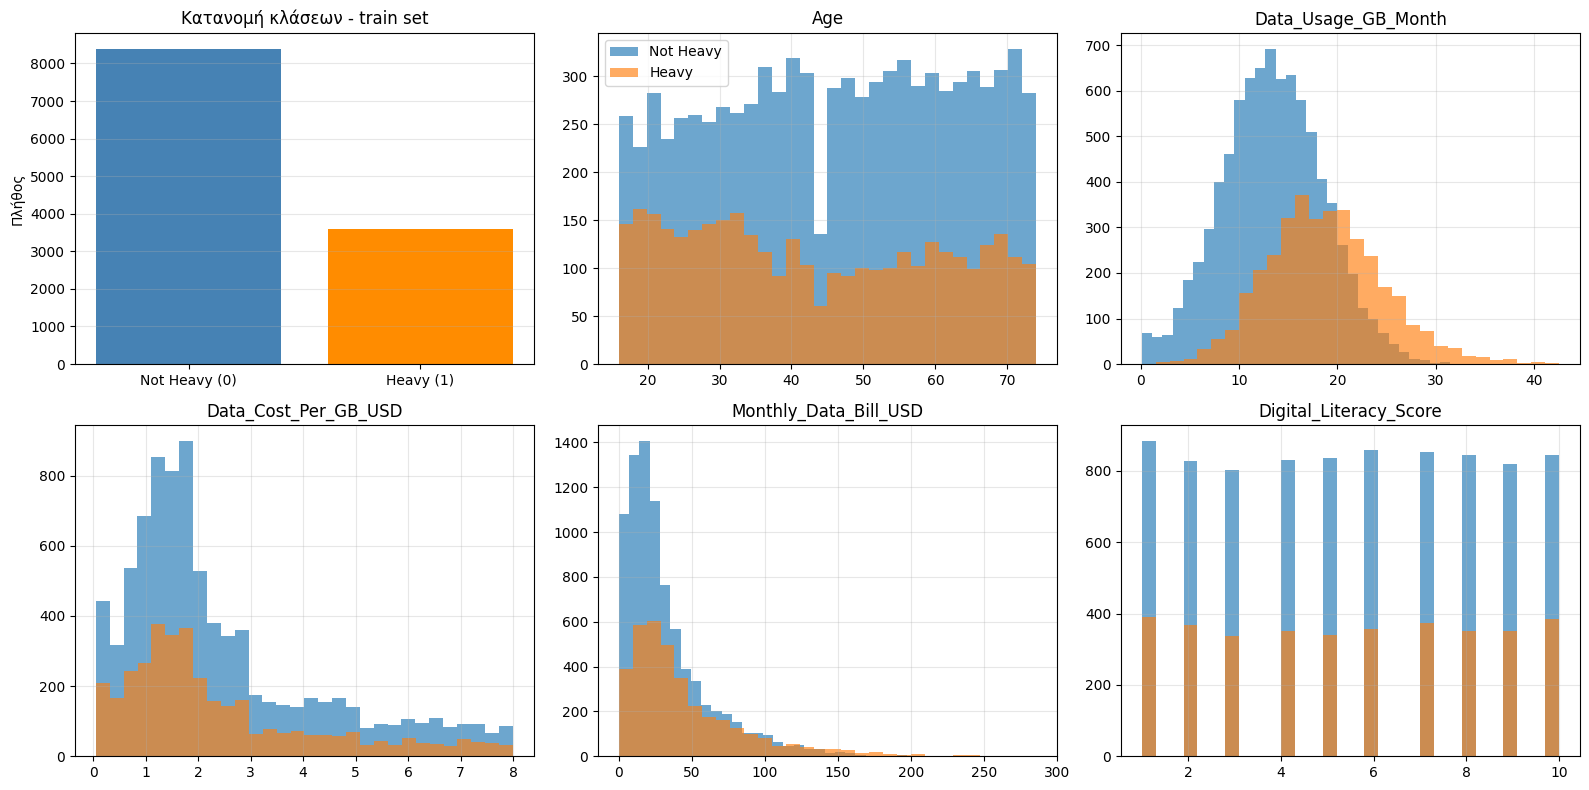

In [ ]:
# Κατανομή target και βασικών αριθμητικών χαρακτηριστικών στο train set.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

counts = y_train.value_counts().sort_index()
axes[0].bar(["Not Heavy (0)", "Heavy (1)"], counts.values, color=["steelblue", "darkorange"])
axes[0].set_title("Κατανομή κλάσεων - train set")
axes[0].set_ylabel("Πλήθος")
axes[0].grid(axis="y", alpha=0.3)

for ax, col in zip(axes[1:], numeric_features):
    ax.hist(train_eda.loc[train_eda["Heavy_AI_User"] == 0, col], bins=30, alpha=0.65, label="Not Heavy")
    ax.hist(train_eda.loc[train_eda["Heavy_AI_User"] == 1, col], bins=30, alpha=0.65, label="Heavy")
    ax.set_title(col)
    ax.grid(alpha=0.3)

axes[1].legend()
plt.tight_layout()
plt.show()

Heavy rate ανά Device_Type:


,mean,count
Device_Type,,
Laptop,0.349,3002
Desktop,0.349,1177
Tablet,0.309,628
IoT Device,0.286,612
Mobile,0.270,6581



Top χώρες ως προς heavy rate:


,mean,count
Country,,
Nigeria,0.325,818
Germany,0.324,757
India,0.318,861
Brazil,0.316,797
USA,0.312,808
South Korea,0.311,805
Japan,0.310,816
China,0.307,817
South Africa,0.306,817



Heavy rate ανά Primary_AI_Use_Case:


,mean,count
Primary_AI_Use_Case,,
Chatbots,0.347,1393
Gaming AI,0.340,1396
Healthcare Diagnosis,0.334,1319
Research,0.328,1395
Educational Tools,0.324,1379
Content Creation,0.320,1376
Coding,0.312,1308
NaN,0.186,2434


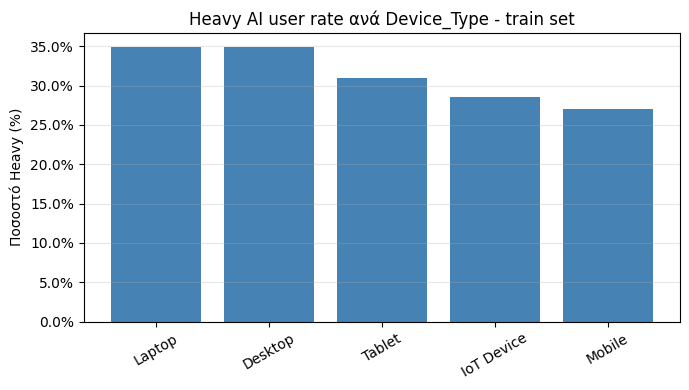

In [ ]:
# Ποσοστό heavy users ανά κατηγορία.
device_rate = (
    train_eda.groupby("Device_Type")["Heavy_AI_User"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

country_rate = (
    train_eda.groupby("Country")["Heavy_AI_User"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

use_case_rate = (
    train_eda.groupby("Primary_AI_Use_Case", dropna=False)["Heavy_AI_User"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print("Heavy rate ανά Device_Type:")
display(device_rate.round(3))

print("\nTop χώρες ως προς heavy rate:")
display(country_rate.head(10).round(3))

print("\nHeavy rate ανά Primary_AI_Use_Case:")
display(use_case_rate.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(device_rate.index, device_rate["mean"] * 100, color="steelblue")
ax.set_title("Heavy AI user rate ανά Device_Type - train set")
ax.set_ylabel("Ποσοστό Heavy (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Προεπεξεργασία Δεδομένων

Η προεπεξεργασία υλοποιείται  με **Pipeline** και **ColumnTransformer**.

1. Αριθμητικά χαρακτηριστικά:
   - `SimpleImputer(strategy="median")`
   - `StandardScaler()`

2. Κατηγορικά χαρακτηριστικά:
   - `SimpleImputer(strategy="most_frequent")`
   - `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`

3. Ανισορροπία:
   - `class_weight="balanced"` σε Logistic Regression και Random Forest

Όλα τα παραπάνω εφαρμόζονται μέσα στα pipelines και σε κάθε fold του cross-validation, το preprocessing κάνει fit μόνο στο training κομμάτι του fold.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 1.3 Επιλογή και Υλοποίηση Μοντέλων

Επιλέγθηκαν τρία μοντέλα:

### Μοντέλο 1: Logistic Regression

Η Logistic Regression είναι γραμμικό πιθανοτικό μοντέλο ταξινόμησης. Είναι κατάλληλη ως ισχυρό baseline, ερμηνεύεται μέσω συντελεστών και υποστηρίζει `class_weight="balanced"`.

### Μοντέλο 2: Bernoulli Naive Bayes

Το Bernoulli Naive Bayes είναι πιθανοτικό μοντέλο που βασίζεται στην υπόθεση υπό συνθήκη ανεξαρτησίας των χαρακτηριστικών. Μετά το one-hot encoding, αποτελεί λογικό baseline για κατηγορική/δυαδικοποιημένη πληροφορία.

### Μοντέλο 3: Random Forest

Το Random Forest είναι ensemble από δέντρα απόφασης. Μπορεί να συλλάβει μη γραμμικές σχέσεις και αλληλεπιδράσεις χαρακτηριστικών.Επίσης μειώνει τη διακύμανση ενός μεμονωμένου δέντρου μέσω bagging.

In [ ]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

pipe_nb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", BernoulliNB()),
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

base_pipelines = {
    "Logistic Regression": pipe_lr,
    "Bernoulli Naive Bayes": pipe_nb,
    "Random Forest": pipe_rf,
}

base_pipelines

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Age', 'Data_Usage_GB_Month',
                                                    'Data_Cost_Per_GB_USD',
                                                    'Monthly_Data_Bill_USD',
                                                    'Digital_Literacy_Score']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(st

## 1.4 Εκπαίδευση και Ρύθμιση Υπερπαραμέτρων

Η επιλογή υπερπαραμέτρων γίνεται με **StratifiedKFold(5)** και **scoring="roc_auc"**.

- Logistic Regression: `GridSearchCV` για **C**
- Bernoulli Naive Bayes: `GridSearchCV` για **alpha**
- Random Forest: `RandomizedSearchCV(n_iter=30)` για **n_estimators**, **max_depth**, **min_samples_leaf**, **max_features**

Οι παράμετροι γράφονται με prefix **clf__**, γιατί το classifier είναι βήμα μέσα σε **Pipeline**.

In [ ]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

### Tuning 1: Logistic Regression - GridSearchCV

In [ ]:
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)

gs_lr.fit(X_train, y_train)

print("Βέλτιστες παράμετροι:", gs_lr.best_params_)
print(f"Καλύτερο CV ROC-AUC: {gs_lr.best_score_:.4f}")

Βέλτιστες παράμετροι: {'clf__C': 0.01}
Καλύτερο CV ROC-AUC: 0.7620


### Tuning 2: Bernoulli Naive Bayes - GridSearchCV

In [ ]:
param_grid_nb = {
    "clf__alpha": [0.01, 0.1, 0.5, 1, 2, 5],
}

gs_nb = GridSearchCV(
    estimator=pipe_nb,
    param_grid=param_grid_nb,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)

gs_nb.fit(X_train, y_train)

print("Βέλτιστες παράμετροι:", gs_nb.best_params_)
print(f"Καλύτερο CV ROC-AUC: {gs_nb.best_score_:.4f}")

Βέλτιστες παράμετροι: {'clf__alpha': 5}
Καλύτερο CV ROC-AUC: 0.7105


### Tuning 3: Random Forest - RandomizedSearchCV

In [ ]:
param_dist_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt", 0.3],
}

# Μειώνουμε το n_iter και το cv για ταχύτητα
rs_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
)

rs_rf.fit(X_train, y_train)

print("Βέλτιστες παράμετροι:")
for key, value in rs_rf.best_params_.items():
    print(f"  {key}: {value}")
print(f"Καλύτερο CV ROC-AUC: {rs_rf.best_score_:.4f}")

Βέλτιστες παράμετροι:
  clf__n_estimators: 200
  clf__min_samples_leaf: 5
  clf__max_features: 0.3
  clf__max_depth: 10
Καλύτερο CV ROC-AUC: 0.7579


In [ ]:
tuned_models = {
    "Logistic Regression": gs_lr.best_estimator_,
    "Bernoulli Naive Bayes": gs_nb.best_estimator_,
    "Random Forest": rs_rf.best_estimator_,
}

cv_best_scores = pd.DataFrame({
    "model": ["Logistic Regression", "Bernoulli Naive Bayes", "Random Forest"],
    "best_cv_roc_auc": [gs_lr.best_score_, gs_nb.best_score_, rs_rf.best_score_],
    "best_params": [gs_lr.best_params_, gs_nb.best_params_, rs_rf.best_params_],
})

display(cv_best_scores)

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.761995,{'clf__C': 0.01}
1,Bernoulli Naive Bayes,0.710477,{'clf__alpha': 5}
2,Random Forest,0.757898,"{'clf__n_estimators': 200, 'clf__min_samples_l..."


## 1.5 Αξιολόγηση Μοντέλων
Λόγω ανισορροπίας 70/30, το accuracy δεν αρκεί. Δίνουμε έμφαση σε:

- Recall για την κλάση 1
- Balanced Accuracy
- ROC-AUC

Παράλληλα υπολογίζουμε precision, F1-score, classification report, confusion matrix και ROC curve.

In [ ]:
def evaluate_model(model, X_part, y_part):
    # Υπολογίζει τις μετρικές ταξινόμησης
    pred = model.predict(X_part)
    proba = model.predict_proba(X_part)[:, 1]

    return {
        "Accuracy": accuracy_score(y_part, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_part, pred),
        "Precision": precision_score(y_part, pred, zero_division=0),
        "Recall": recall_score(y_part, pred, zero_division=0),
        "F1": f1_score(y_part, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_part, proba),
    }

In [ ]:
results_rows = []

for name, model in tuned_models.items():
    train_metrics = evaluate_model(model, X_train, y_train)
    test_metrics = evaluate_model(model, X_test, y_test)

    results_rows.append({"Model": name, "Split": "Train", **train_metrics})
    results_rows.append({"Model": name, "Split": "Test", **test_metrics})

results_df = pd.DataFrame(results_rows)
display(results_df.round(4))

test_results = (
    results_df[results_df["Split"] == "Test"]
    .sort_values(["ROC-AUC", "Recall", "Balanced Accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Κατάταξη μοντέλων στο test set:")
display(test_results.round(4))

,Model,Split,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Train,0.6934,0.6896,0.4926,0.6802,0.5714,0.7654
1,Logistic Regression,Test,0.6947,0.6865,0.4938,0.6659,0.5671,0.7626
2,Bernoulli Naive Bayes,Train,0.7147,0.6145,0.5371,0.3637,0.4337,0.7217
3,Bernoulli Naive Bayes,Test,0.7160,0.6159,0.5402,0.3651,0.4358,0.7147
4,Random Forest,Train,0.7677,0.7573,0.5917,0.7315,0.6542,0.8468
5,Random Forest,Test,0.7150,0.6902,0.5212,0.6282,0.5697,0.7618


Κατάταξη μοντέλων στο test set:


,Model,Split,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Test,0.6947,0.6865,0.4938,0.6659,0.5671,0.7626
1,Random Forest,Test,0.7150,0.6902,0.5212,0.6282,0.5697,0.7618
2,Bernoulli Naive Bayes,Test,0.7160,0.6159,0.5402,0.3651,0.4358,0.7147


In [ ]:
for name, model in tuned_models.items():
    pred_test = model.predict(X_test)

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(
        y_test,
        pred_test,
        target_names=["Not Heavy (0)", "Heavy (1)"],
        zero_division=0,
    ))


Logistic Regression
               precision    recall  f1-score   support

Not Heavy (0)       0.83      0.71      0.76      2099
    Heavy (1)       0.49      0.67      0.57       901

     accuracy                           0.69      3000
    macro avg       0.66      0.69      0.67      3000
 weighted avg       0.73      0.69      0.70      3000


Bernoulli Naive Bayes
               precision    recall  f1-score   support

Not Heavy (0)       0.76      0.87      0.81      2099
    Heavy (1)       0.54      0.37      0.44       901

     accuracy                           0.72      3000
    macro avg       0.65      0.62      0.62      3000
 weighted avg       0.69      0.72      0.70      3000


Random Forest
               precision    recall  f1-score   support

Not Heavy (0)       0.82      0.75      0.79      2099
    Heavy (1)       0.52      0.63      0.57       901

     accuracy                           0.71      3000
    macro avg       0.67      0.69      0.68      300

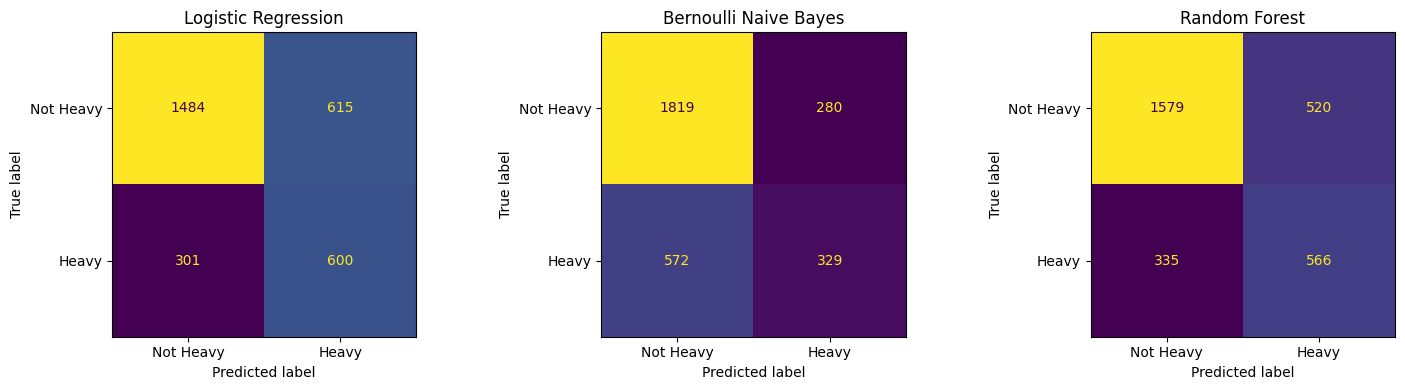

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, tuned_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Not Heavy", "Heavy"],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

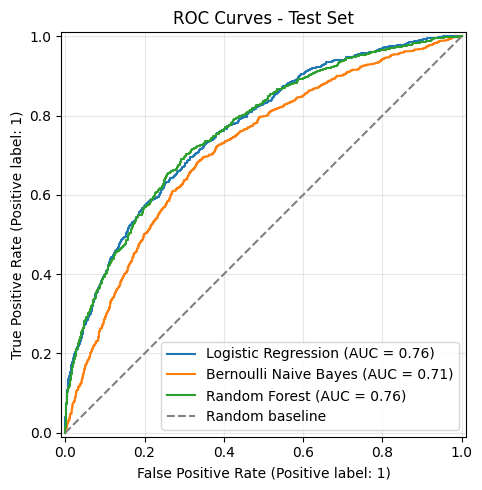

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_title("ROC Curves - Test Set")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 1.6 Συγκριτική Ανάλυση Αποτελεσμάτων

### Α. Σταθερότητα - Cross-validation mean ± std

In [ ]:
stability_rows = []
scoring_map = {
    "ROC-AUC": "roc_auc",
    "Balanced Accuracy": "balanced_accuracy",
    "Recall": "recall",
}

for name, model in tuned_models.items():
    for metric_name, scoring in scoring_map.items():
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=-1,
        )
        stability_rows.append({
            "Model": name,
            "Metric": metric_name,
            "CV mean": scores.mean(),
            "CV std": scores.std(),
        })

stability_df = pd.DataFrame(stability_rows)
display(stability_df.round(4))

,Model,Metric,CV mean,CV std
0,Logistic Regression,ROC-AUC,0.7620,0.0063
1,Logistic Regression,Balanced Accuracy,0.6860,0.0066
2,Logistic Regression,Recall,0.6746,0.0171
3,Bernoulli Naive Bayes,ROC-AUC,0.7105,0.0128
4,Bernoulli Naive Bayes,Balanced Accuracy,0.5997,0.0134
5,Bernoulli Naive Bayes,Recall,0.3404,0.0186
6,Random Forest,ROC-AUC,0.7576,0.0062
7,Random Forest,Balanced Accuracy,0.6798,0.0074
8,Random Forest,Recall,0.6114,0.0152


### Β. Overfitting - Train vs Test gap

,Train ROC-AUC,Test ROC-AUC,ROC-AUC Gap,Train Balanced Accuracy,Test Balanced Accuracy,Balanced Accuracy Gap
Model,,,,,,
Logistic Regression,0.7654,0.7626,0.0028,0.6896,0.6865,0.0032
Random Forest,0.8468,0.7618,0.0850,0.7573,0.6902,0.0671
Bernoulli Naive Bayes,0.7217,0.7147,0.0070,0.6145,0.6159,-0.0013


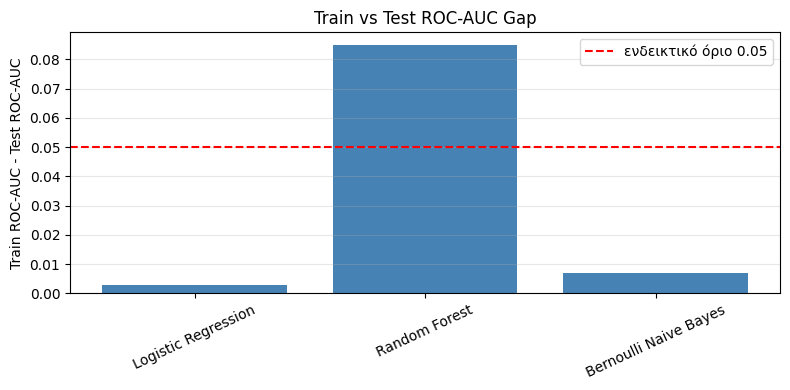

In [ ]:
train_table = results_df[results_df["Split"] == "Train"].set_index("Model")
test_table = results_df[results_df["Split"] == "Test"].set_index("Model")

gap_df = pd.DataFrame({
    "Train ROC-AUC": train_table["ROC-AUC"],
    "Test ROC-AUC": test_table["ROC-AUC"],
    "ROC-AUC Gap": train_table["ROC-AUC"] - test_table["ROC-AUC"],
    "Train Balanced Accuracy": train_table["Balanced Accuracy"],
    "Test Balanced Accuracy": test_table["Balanced Accuracy"],
    "Balanced Accuracy Gap": train_table["Balanced Accuracy"] - test_table["Balanced Accuracy"],
}).sort_values("Test ROC-AUC", ascending=False)

display(gap_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(gap_df.index, gap_df["ROC-AUC Gap"], color="steelblue")
ax.axhline(0.05, color="red", linestyle="--", label="ενδεικτικό όριο 0.05")
ax.set_title("Train vs Test ROC-AUC Gap")
ax.set_ylabel("Train ROC-AUC - Test ROC-AUC")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Γ. Σύγκριση test μετρικών

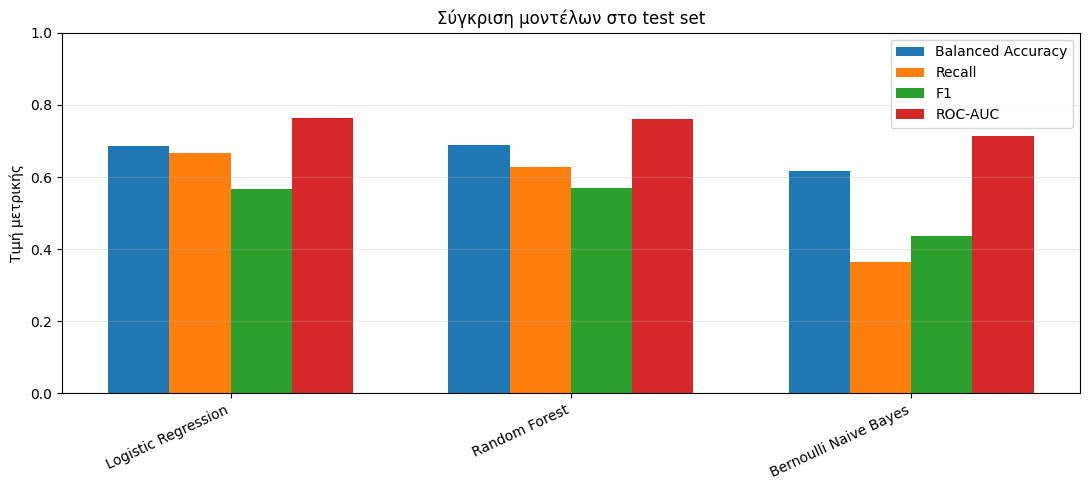

In [ ]:
plot_metrics = ["Balanced Accuracy", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(test_results["Model"]))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(plot_metrics):
    ax.bar(x + i * width, test_results[metric], width=width, label=metric)

ax.set_xticks(x + width * (len(plot_metrics) - 1) / 2)
ax.set_xticklabels(test_results["Model"], rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Τιμή μετρικής")
ax.set_title("Σύγκριση μοντέλων στο test set")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Δ. Ερμηνεία: ποιος είναι ο heavy χρήστης AI;

Χρησιμοποιούμε δύο συμπληρωματικές προσεγγίσεις:

- Συντελεστές Logistic Regression, επειδή το μοντέλο είναι ερμηνεύσιμο
- Feature importances Random Forest, επειδή δείχνουν ποια χαρακτηριστικά χρησιμοποιούνται συχνότερα στα δέντρα

In [ ]:
def clean_feature_name(name):
    # Καθαρισμός ονομάτων από ColumnTransformer για πιο ευανάγνωστους πίνακες.
    return name.replace("num__", "").replace("cat__", "")


lr_model = tuned_models["Logistic Regression"]
feature_names = lr_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [clean_feature_name(name) for name in feature_names]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.named_steps["clf"].coef_[0],
})

print("Logistic Regression - ισχυρότεροι θετικοί συντελεστές:")
display(coef_df.sort_values("Coefficient", ascending=False).head(15).round(4))

print("\nLogistic Regression - ισχυρότεροι αρνητικοί συντελεστές:")
display(coef_df.sort_values("Coefficient", ascending=True).head(15).round(4))

Logistic Regression - ισχυρότεροι θετικοί συντελεστές:


,Feature,Coefficient
1,Data_Usage_GB_Month,0.9893
26,State_Berlin,0.1254
117,Device_Type_Laptop,0.1210
122,Primary_AI_Use_Case_Chatbots,0.1068
115,Device_Type_Desktop,0.1067
43,State_Guangdong,0.1007
42,State_Georgia,0.0968
100,State_Telangana,0.0908
111,State_Île-de-France,0.0863
94,State_Seoul,0.0737



Logistic Regression - ισχυρότεροι αρνητικοί συντελεστές:


,Feature,Coefficient
126,Primary_AI_Use_Case_Gaming AI,-0.2654
118,Device_Type_Mobile,-0.1828
0,Age,-0.1451
76,State_Nouvelle-Aquitaine,-0.0941
73,State_North Rhine-Westphalia,-0.0875
5,Country_Australia,-0.0861
18,Country_UK,-0.0832
104,State_Victoria,-0.0783
57,State_Jiangsu,-0.0768
9,Country_France,-0.0741


Random Forest - σημαντικότερα χαρακτηριστικά:


,Feature,Importance
1,Data_Usage_GB_Month,0.5532
3,Monthly_Data_Bill_USD,0.1104
2,Data_Cost_Per_GB_USD,0.0730
0,Age,0.0662
4,Digital_Literacy_Score,0.0260
126,Primary_AI_Use_Case_Gaming AI,0.0200
118,Device_Type_Mobile,0.0103
117,Device_Type_Laptop,0.0081
112,Gender_Female,0.0056
120,Has_5G_Access_No,0.0055


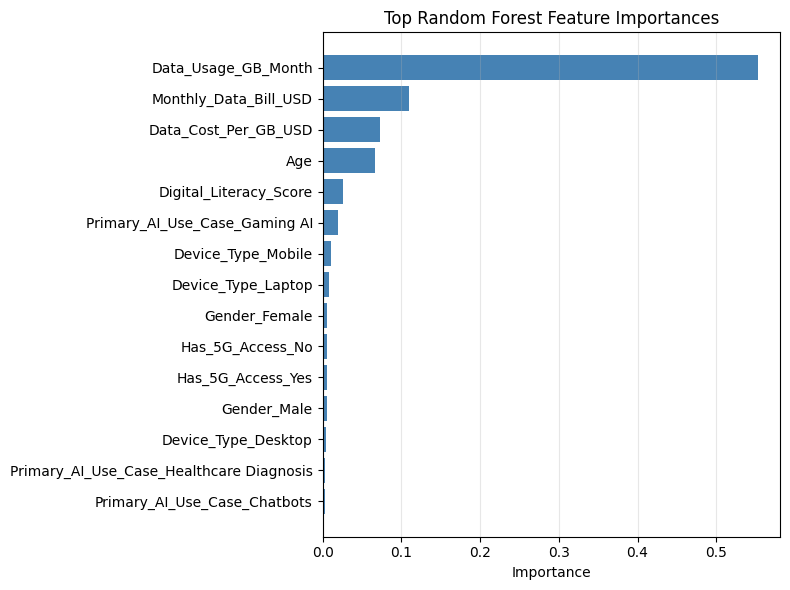

In [ ]:
rf_model = tuned_models["Random Forest"]
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_feature_names = [clean_feature_name(name) for name in rf_feature_names]

importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.named_steps["clf"].feature_importances_,
}).sort_values("Importance", ascending=False)

print("Random Forest - σημαντικότερα χαρακτηριστικά:")
display(importance_df.head(20).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
top_imp = importance_df.head(15).iloc[::-1]
ax.barh(top_imp["Feature"], top_imp["Importance"], color="steelblue")
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Ε. Συμπεράσματα Συγκριτικής Ανάλυσης

Μετά την εκτέλεση του notebook, συμπληρώνουμε το τελικό συμπέρασμα με βάση τον πίνακα `test_results`, το `stability_df` και το `gap_df`.

Κριτήρια επιλογής καλύτερου μοντέλου:

- Υψηλό ROC-AUC
- Υψηλό Recall για την κλάση **Heavy (1)**
- Υψηλό Balanced Accuracy
- Μικρό train-test gap
- Χαμηλή τυπική απόκλιση στο cross-validation



In [ ]:
best_model_row = test_results.iloc[0]

print("Προτεινόμενο καλύτερο μοντέλο με βάση test ROC-AUC, Recall και Balanced Accuracy:")
print(f"Μοντέλο: {best_model_row['Model']}")
print(f"ROC-AUC: {best_model_row['ROC-AUC']:.4f}")
print(f"Recall κλάσης 1: {best_model_row['Recall']:.4f}")
print(f"Balanced Accuracy: {best_model_row['Balanced Accuracy']:.4f}")
print(f"F1: {best_model_row['F1']:.4f}")



Προτεινόμενο καλύτερο μοντέλο με βάση test ROC-AUC, Recall και Balanced Accuracy:
Μοντέλο: Logistic Regression
ROC-AUC: 0.7626
Recall κλάσης 1: 0.6659
Balanced Accuracy: 0.6865
F1: 0.5671
